# Notebook 02: Engagement, Installs and Revenue Models in Auto & Vehicles Apps

*Valvoline App Market Analysis · Part 2 of 2 · Python, pandas, scikit-learn, Plotly*

Uses `df_clean.parquet`, built in **`01_data_cleaning_and_join.ipynb`**. The sections follow the business questions in the client presentation.

**Context.** Valvoline's Instant Oil Change app (listed under Shopping) books service visits but gives drivers no reason to open it between them. The team proposed **Car Care Companion**, a maintenance-tracking app for Google Play's Auto & Vehicles category, and used this analysis to test the idea.

**Questions answered here**
- **Q2 (primary): Do recurring-use apps earn deeper engagement than one-time apps?** Yes. Recurring apps (maintenance trackers, reminders, logs) earn **2.0×** the median ratings per install of one-time apps such as store locators (0.025 vs 0.012), and rate **0.45★** higher (4.22★ vs 3.77★).
- **Q3: What predicts installs, and do permissions matter?** In the Auto & Vehicles model, Rating Count and Rating carry about **88%** of the importance; all 12 permission features together carry about **4%**. Rating Count partly *results from* installs (more users leave more reviews), so it signals engagement rather than being a lever on its own.
- **Q4: Which revenue model should the app use?** **97.7%** of 4.0★+ Auto & Vehicles apps are free to download, and the most common model (58.2%) is free with no ads or in-app purchases.

The presentation's Q1 (how the category ranks on ratings) is not calculated in these notebooks.

**Limitations**
- The data is a June 2021 snapshot.
- Recurring/One-Time tags come from keyword matching on app names, and the groups are small (35 and 26 apps). None of the 35 recurring apps requests Calendar access, so the tags could not be cross-checked against permissions. The gap has not been tested for statistical significance.
- Feature importance measures association, not cause, and Random Forest importance favors continuous columns with many distinct values, such as Rating Count.
- My Firestone doesn't match the tagging patterns, so it is placed with the recurring apps by hand. Valvoline's app is listed under Shopping, so it is compared with Auto & Vehicles apps rather than modeled with them.
- "Minimum Installs" is Google Play's install bucket (for example 100,000+), not an exact count.

## 1. Setup
Runs in Google Colab and reads the data from Google Drive. `kaleido` lets Plotly export static PNGs.

In [ ]:
from google.colab import drive, files
drive.mount('/content/drive')

!pip install -q "kaleido==0.2.1"

import os
import re
import numpy as np
import pandas as pd
import plotly.express as px
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

Mounted at /content/drive


## 2. Load the data
`df_clean.parquet` from notebook 01: one row per app (988,310 apps, 44 columns), with app metadata joined to engineered permission features.

In [ ]:
df = pd.read_parquet('/content/drive/MyDrive/Colab Notebooks/df_clean.parquet')
print(df.shape)                          # expect 988,310 rows
print(df["permission_types"].head())     # expect text with semicolons
print(df["Monetization_Type"].value_counts())

(988310, 44)
1                                                 Other
6                                                 Other
7     Calendar; Camera; Contacts; Device ID & call i...
9     Other; Photos/Media/Files; Storage; Wi-Fi conn...
10                                                Other
Name: permission_types, dtype: object
Monetization_Type
Free+Ads        480668
Free            348526
Free+IAP+Ads    105280
Free+IAP         32419
Paid             21417
Name: count, dtype: int64


## 3. Scope: Auto & Vehicles and the named apps
Car Care Companion would be listed under **Auto & Vehicles** (7,403 apps), so the category models and charts use only that category. Only 177 apps in it request Calendar access, which matters for the cross-check in section 4.

In [ ]:
# What categories exist that look like ours?
print(df[df["Category"].str.contains("Auto", case=False, na=False)]["Category"].value_counts())

SCOPE_CATEGORIES = ["Auto & Vehicles"]        # widen here if needed, e.g. + ["Productivity", "Lifestyle"]
scope = df[df["Category"].isin(SCOPE_CATEGORIES)].copy()

print(f"Apps in scope: {len(scope):,}")
print(f"Apps requesting Calendar: {scope['perm_Calendar'].sum():,}")
print(scope["Rating"].describe())

Category
Auto & Vehicles    7403
Name: count, dtype: int64
Apps in scope: 7,403
Apps requesting Calendar: 177
count    7403.000000
mean        3.845995
std         0.765824
min         1.000000
25%         3.400000
50%         4.000000
75%         4.400000
max         5.000000
Name: Rating, dtype: float64


**Named apps.** My Firestone, the closest competitor, is found by searching app names. Valvoline's Instant Oil Change app is looked up by its App Id.

In [ ]:
COMPETITOR_NAME = "firestone"
matches = df[df["App Name"].str.contains(COMPETITOR_NAME, case=False, na=False, regex=False)]
display(matches[["App Name", "App Id", "Category", "Rating", "Rating Count", "Minimum Installs"]])

,App Name,App Id,Category,Rating,Rating Count,Minimum Installs
786005,Firestone AG Tyres,co.uk.rnfmobile.firestone.tpc,Productivity,3.7,95.0,10000.0
1230498,Firestone Walker Invitational,com.propaganda3.firestonewalker,Food & Drink,4.4,12.0,1000.0
1317326,My Firestone,com.bsro.fcac,Auto & Vehicles,3.5,1972.0,100000.0


In [ ]:
VALVOLINE_ID = "com.mobile.vioc"
valvoline = df[df["App Id"] == VALVOLINE_ID]
display(valvoline.T)   # transposed so the whole row is readable

,863709
App Name,Valvoline Instant Oil Change
App Id,com.mobile.vioc
Category,Shopping
Rating,4.4
Rating Count,2454.0
Installs,"100,000+"
Minimum Installs,100000.0
Maximum Installs,264063
Free,True
Price,0.0


## 4. Q2 (primary): Do recurring-use apps earn deeper engagement?
**Tagging.** Each Auto & Vehicles app is tagged by keyword patterns in its name:
- **Recurring:** apps people return to, such as maintenance trackers, service reminders, and mileage or fuel logs.
- **One-Time:** apps opened for a single task, such as store locators, finders and directories.

Names that match unrelated topics (racing games, dash cams, radio, insurance quotes, …) are excluded, and apps matching neither list stay untagged.

In [ ]:
import re

RECURRING_PATTERNS = [
    r"\bmaintenance track(er|ing)?\b",
    r"\bservice remind(er)?\b",
    r"\boil change remind(er)?\b",
    r"\bmileage log(s|ger|book|ging)?\b",
    r"\bvehicle log(s|ger|book|ging)?\b",
    r"\bcar log(s|ger|book|ging)?\b",
    r"\bmaintenance log(s|ger|book|ging)?\b",
    r"\bfuel log(s|ger|book|ging)?\b",
    r"\bservice due\b",
    r"\brepair track(er)?\b",
]

ONE_TIME_PATTERNS = [
    r"\blocator\b", r"\bfinder\b", r"\bnear me\b", r"\bdirectory\b",
    r"\bstore locator\b", r"\bdealer locator\b", r"\bmap\b",
]

EXCLUDE_PATTERNS = [
    r"\brace\b", r"\bdrift\b", r"\bgps navigat\w*\b", r"\bdash ?cam\b",
    r"\bradio\b", r"\bmusic\b", r"\bvideo\b", r"\bparking meter\b",
    r"\bfuel price\b", r"\binsurance quote\b",
]

def tag_utility_type(name):
    name_lower = str(name).lower()
    if any(re.search(p, name_lower) for p in EXCLUDE_PATTERNS):
        return None
    if any(re.search(p, name_lower) for p in RECURRING_PATTERNS):
        return "Recurring"
    elif any(re.search(p, name_lower) for p in ONE_TIME_PATTERNS):
        return "One-Time"
    return None

scope["Utility_Type"] = scope["App Name"].apply(tag_utility_type)
tagged = scope[scope["Utility_Type"].notna()].copy()
print(tagged["Utility_Type"].value_counts())

Utility_Type
Recurring    35
One-Time     26
Name: count, dtype: int64


The tagged list is saved so every tag can be checked by hand.

In [ ]:
review = tagged[["App Name", "Utility_Type", "Rating Count", "Minimum Installs"]].sort_values("Utility_Type")
review.to_csv("/content/sample_data/utility_type_review.csv", index=False)
print(f"Exported {len(review)} rows for manual review.")

Exported 61 rows for manual review.


**Cross-check with permissions.** Recurring apps send reminders, so some should request Calendar access. None do, so the tags rest on app names alone (see Limitations).

In [ ]:
tagged["Recurring_Confirmed"] = (tagged["Utility_Type"] == "Recurring") & (tagged["perm_Calendar"] == True)
print(f"Name-tagged Recurring: {(tagged['Utility_Type']=='Recurring').sum()}")
print(f"Recurring AND requests Calendar access: {tagged['Recurring_Confirmed'].sum()}")

Name-tagged Recurring: 35
Recurring AND requests Calendar access: 0


**Engagement and ratings.** *Engagement ratio* = Rating Count ÷ Minimum Installs: the share of installers who left a rating. Apps with zero installs are dropped to avoid dividing by zero. The ratios are skewed (two apps exceed 0.5), so compare the medians: the means are close, but the typical recurring app earns about twice the ratings per install.

In [ ]:
tagged = tagged[tagged["Minimum Installs"] > 0].copy()
tagged["engagement_ratio"] = tagged["Rating Count"] / tagged["Minimum Installs"]
print(tagged.groupby("Utility_Type")["engagement_ratio"].describe())

              count      mean       std     min       25%     50%     75%  \
Utility_Type                                                                
One-Time       26.0  0.043683  0.133129  0.0032  0.006475  0.0122  0.0140   
Recurring      35.0  0.049018  0.093055  0.0069  0.015480  0.0250  0.0409   

               max  
Utility_Type        
One-Time      0.67  
Recurring     0.55  


In [ ]:
print(tagged.groupby("Utility_Type")["Rating"].agg(["mean", "median", "count"]))

                  mean  median  count
Utility_Type                         
One-Time      3.765385     3.8     26
Recurring     4.222857     4.2     35


**Where Valvoline and Firestone sit.** Both have 100,000+ installs. Valvoline's app is rated higher and gets about 24% more ratings per install.

In [ ]:
FIRESTONE_ID = "com.bsro.fcac"
VALVOLINE_ID = "com.mobile.vioc"

firestone_row = df[df["App Id"] == FIRESTONE_ID].copy()
valvoline_row = df[df["App Id"] == VALVOLINE_ID].copy()

for label, row in [("Firestone", firestone_row), ("Valvoline", valvoline_row)]:
    r = row.iloc[0]
    ratio = r["Rating Count"] / r["Minimum Installs"]
    print(f"{label}: Installs={r['Minimum Installs']:,.0f}  RatingCount={r['Rating Count']:,.0f}  Ratio={ratio:.4f}")

Firestone: Installs=100,000  RatingCount=1,972  Ratio=0.0197
Valvoline: Installs=100,000  RatingCount=2,454  Ratio=0.0245


In [ ]:
for label, row in [("Firestone", firestone_row), ("Valvoline (Instant Oil Change)", valvoline_row)]:
    r = row.iloc[0]
    print(f"{label}: Rating = {r['Rating']:.2f}  (Rating Count = {r['Rating Count']:,.0f}, Installs = {r['Minimum Installs']:,.0f})")

Firestone: Rating = 3.50  (Rating Count = 1,972, Installs = 100,000)
Valvoline (Instant Oil Change): Rating = 4.40  (Rating Count = 2,454, Installs = 100,000)


### How the primary chart evolved
**Iteration 1: baseline.** On a linear scale, two outliers (0.55 and 0.67) squash the other 59 apps near zero.

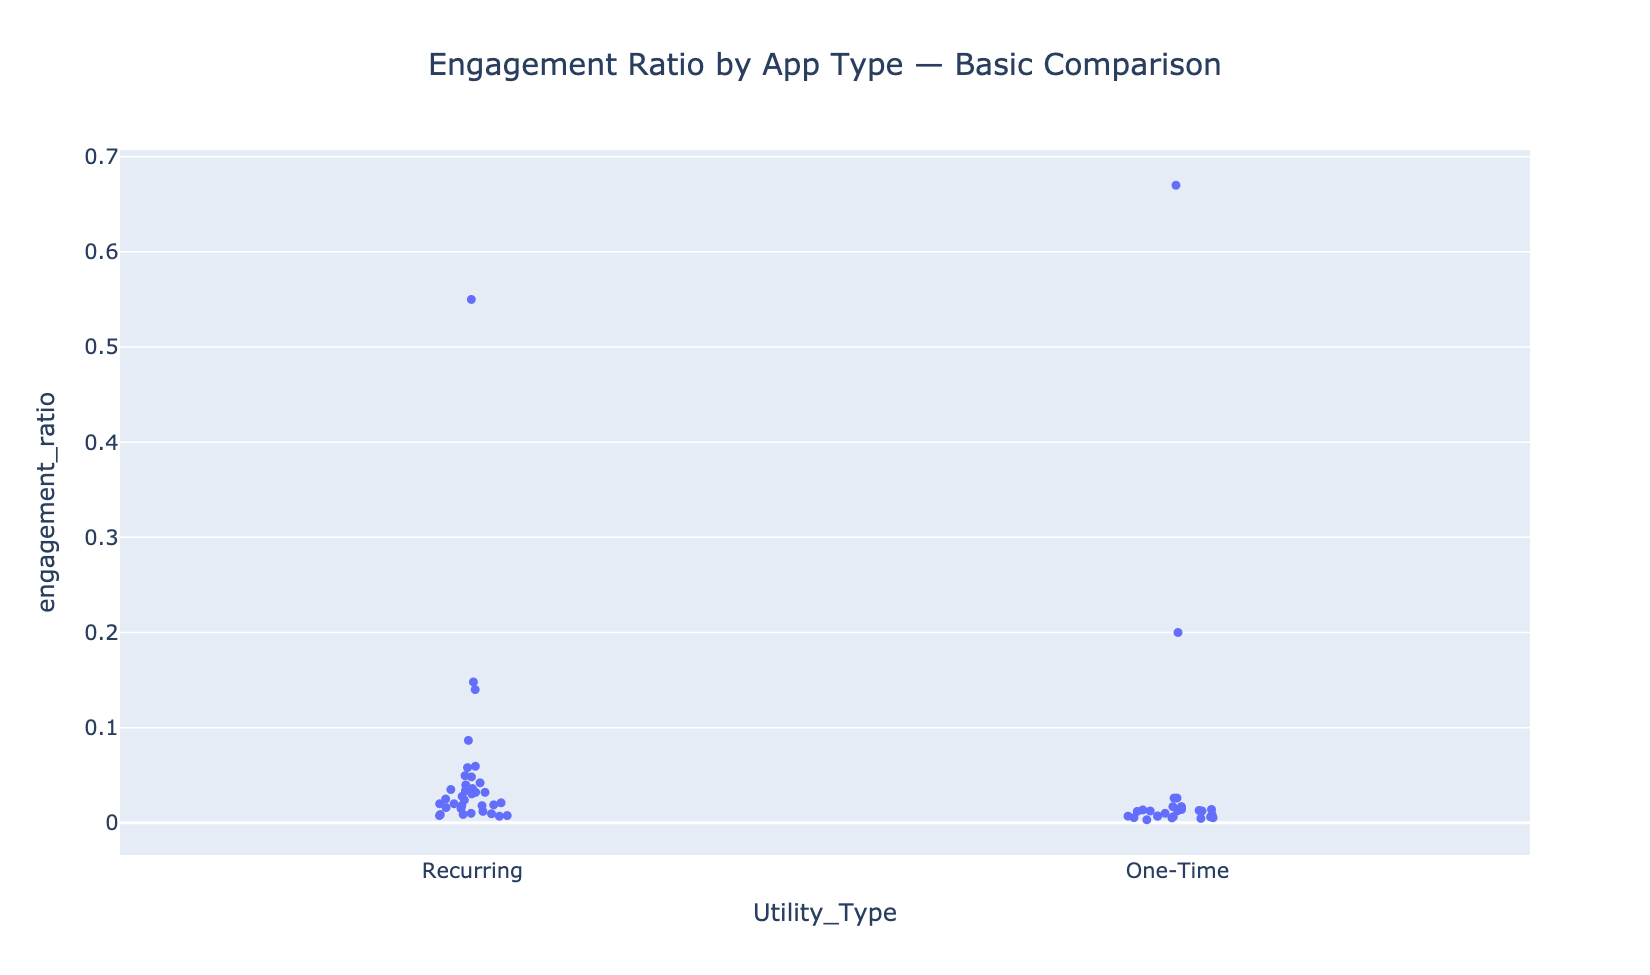

In [ ]:
fig3a = px.strip(tagged, x="Utility_Type", y="engagement_ratio",
                  title="Iteration 1: Engagement Ratio by Utility Type (Auto & Vehicles)")
fig3a.update_layout(
    title="Engagement Ratio by App Type — Basic Comparison",
    title_x=0.5, title_font_size=20,
    xaxis=dict(title_font_size=16, tickfont_size=14),
    yaxis=dict(title_font_size=16, tickfont_size=14),
)
fig3a.write_html("/content/sample_data/chart3_iter1_basic.html")
fig3a.show()

**Iteration 2: log scale and color.** The log axis spreads out the range where most apps sit. The bottom quarter of recurring apps (0.015) out-engages the top quarter of one-time apps (0.014).

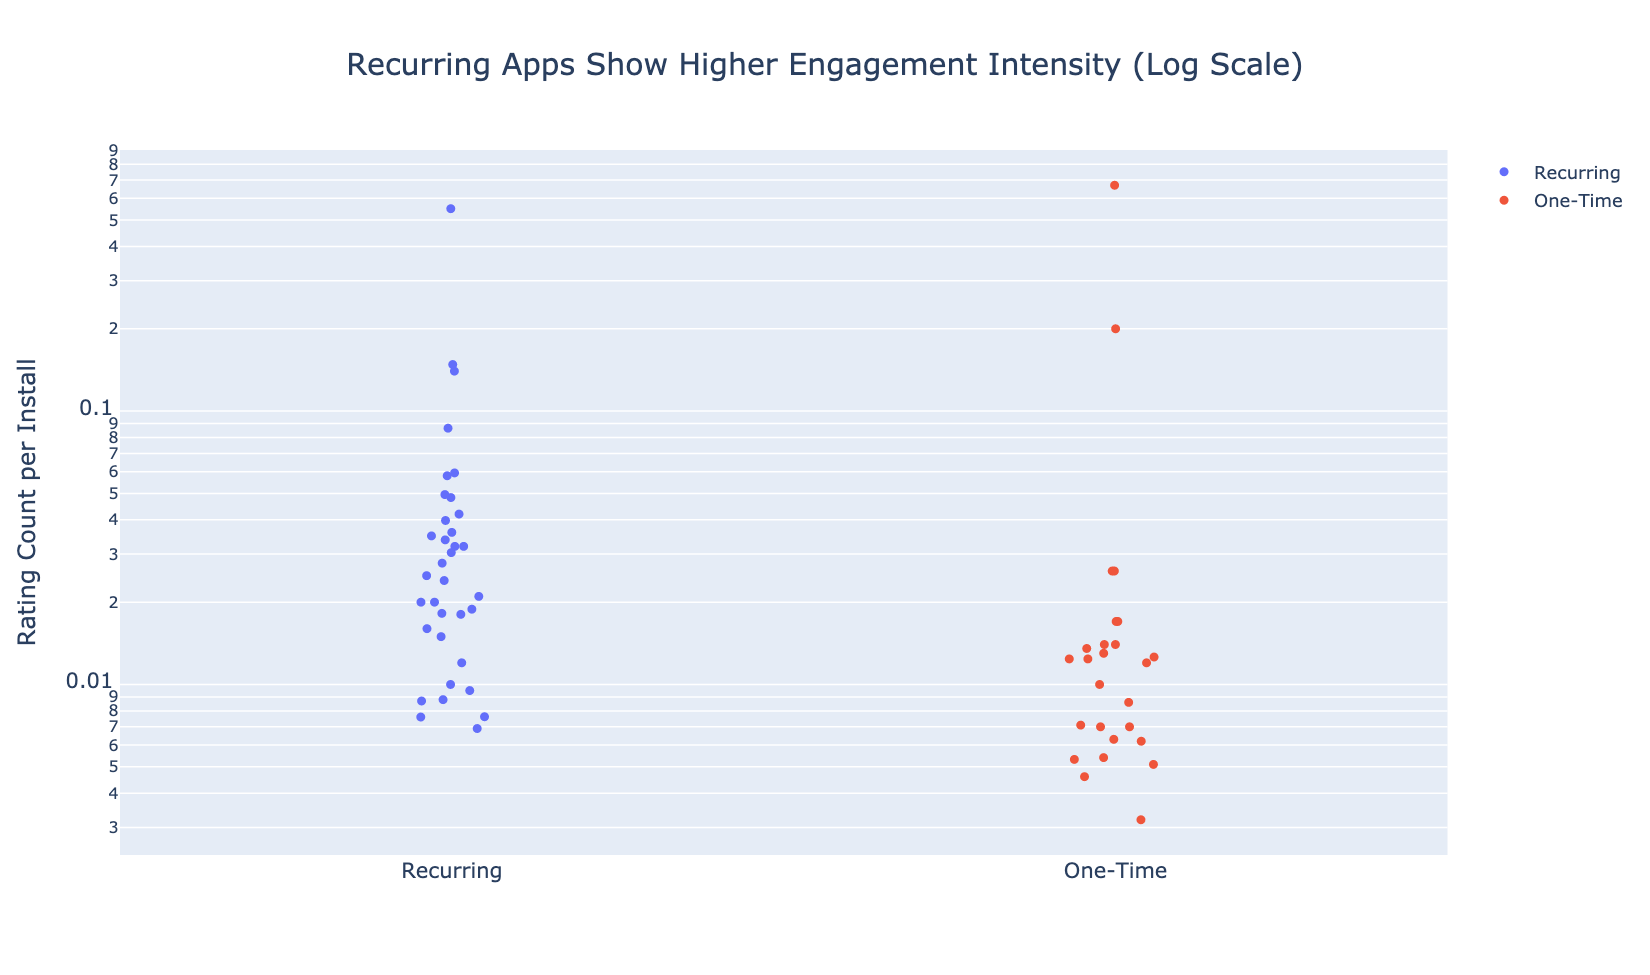

In [ ]:
fig3b = px.strip(tagged, x="Utility_Type", y="engagement_ratio", color="Utility_Type",
                  hover_name="App Name",
                  hover_data={"Rating Count": True, "Minimum Installs": ":,", "Utility_Type": False},
                  title="Iteration 2: Recurring Apps Show Higher Engagement Intensity",
                  labels={"engagement_ratio": "Rating Count per Install", "Utility_Type": ""})
fig3b.update_yaxes(type="log")
fig3b.update_layout(
    title="Recurring Apps Show Higher Engagement Intensity (Log Scale)",
    title_x=0.5, title_font_size=20,
    xaxis=dict(title_font_size=16, tickfont_size=14),
    yaxis=dict(title_font_size=16, tickfont_size=14),
)
fig3b.write_html("/content/sample_data/chart3_iter2_styled.html")
fig3b.show()

**Iteration 3: named competitors.** Valvoline and Firestone added as stars. Firestone isn't one of the 61 tagged apps; it is placed in the Recurring column by hand as the closest service-brand competitor to the proposed app. Valvoline's app is a one-time booking app.

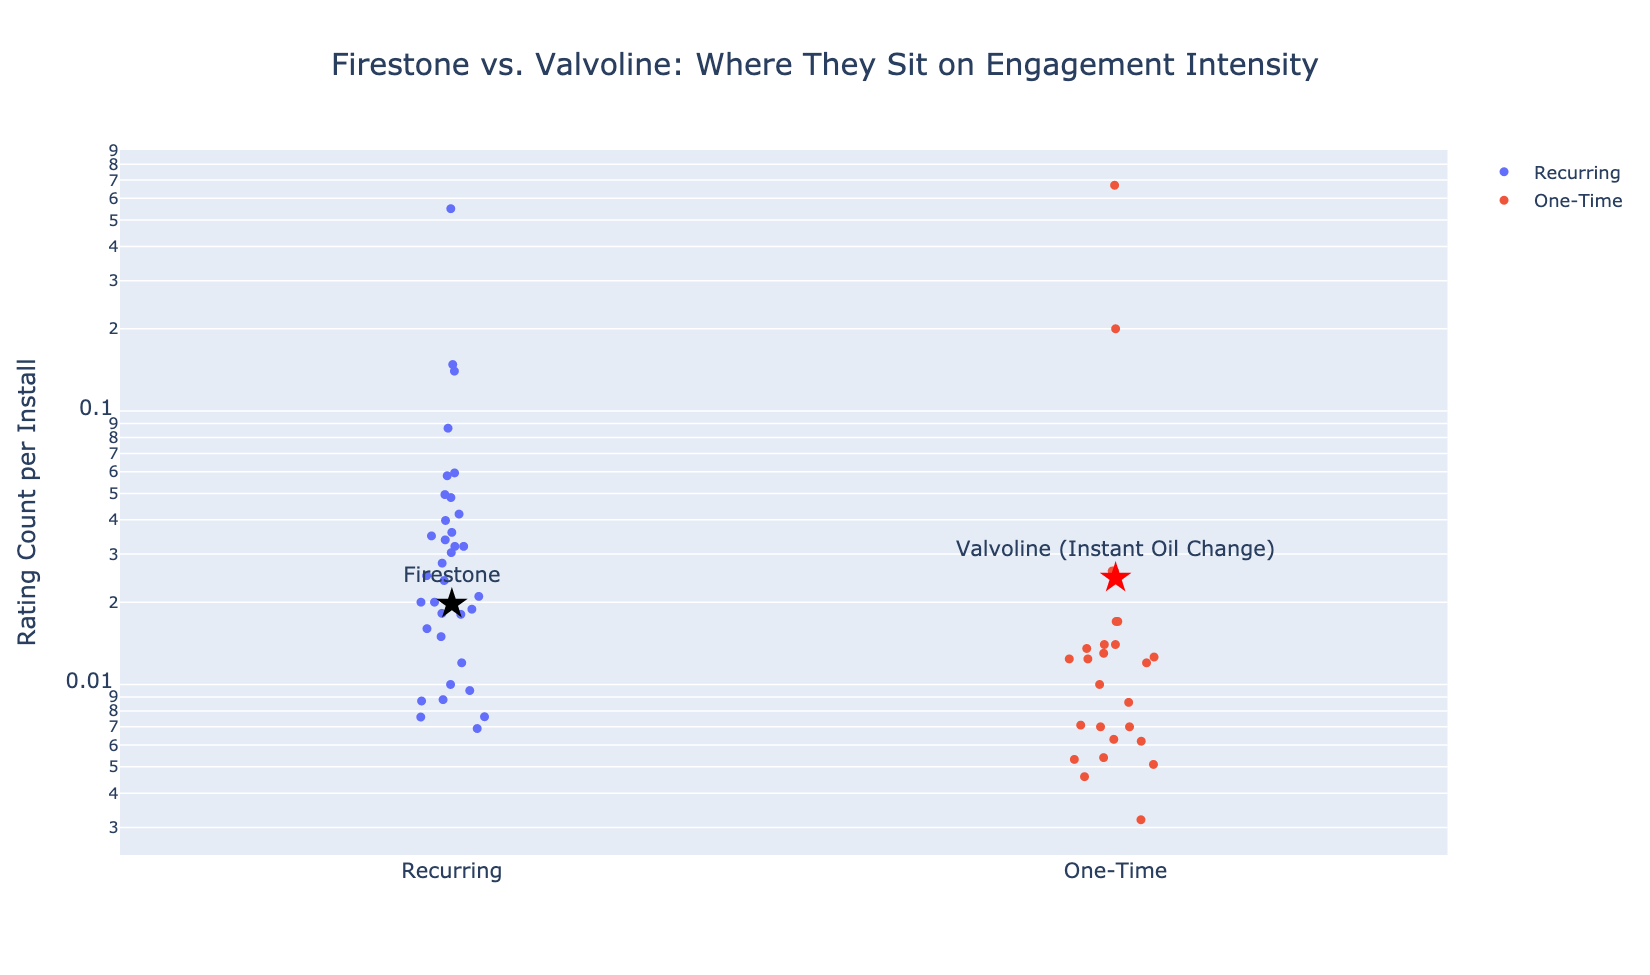

In [ ]:
fig3c = px.strip(tagged, x="Utility_Type", y="engagement_ratio", color="Utility_Type",
                  hover_name="App Name",
                  hover_data={"Rating Count": True, "Minimum Installs": ":,", "Utility_Type": False},
                  title="Where Firestone and Valvoline Sit on Engagement Intensity",
                  labels={"engagement_ratio": "Rating Count per Install", "Utility_Type": ""})
fig3c.update_yaxes(type="log")

overlays = [
    ("Firestone", firestone_row, "Recurring", "black"),
    ("Valvoline (Instant Oil Change)", valvoline_row, "One-Time", "red"),
]

for label, row, group, color in overlays:
    r = row.iloc[0]
    ratio = r["Rating Count"] / r["Minimum Installs"]
    fig3c.add_scatter(
        x=[group], y=[ratio], mode="markers+text",
        marker=dict(size=16, color=color, symbol="star"),
        text=[label], textposition="top center", showlegend=False,
        textfont=dict(size=14)
    )

fig3c.update_layout(
    title="Firestone vs. Valvoline: Where They Sit on Engagement Intensity",
    title_x=0.5, title_font_size=20,
    xaxis=dict(title_font_size=16, tickfont_size=14),
    yaxis=dict(title_font_size=16, tickfont_size=14),
)
fig3c.write_html("/content/sample_data/chart3_iter3_annotated.html")
fig3c.show()


**Final (presentation slide 10): engagement with average ratings annotated.**

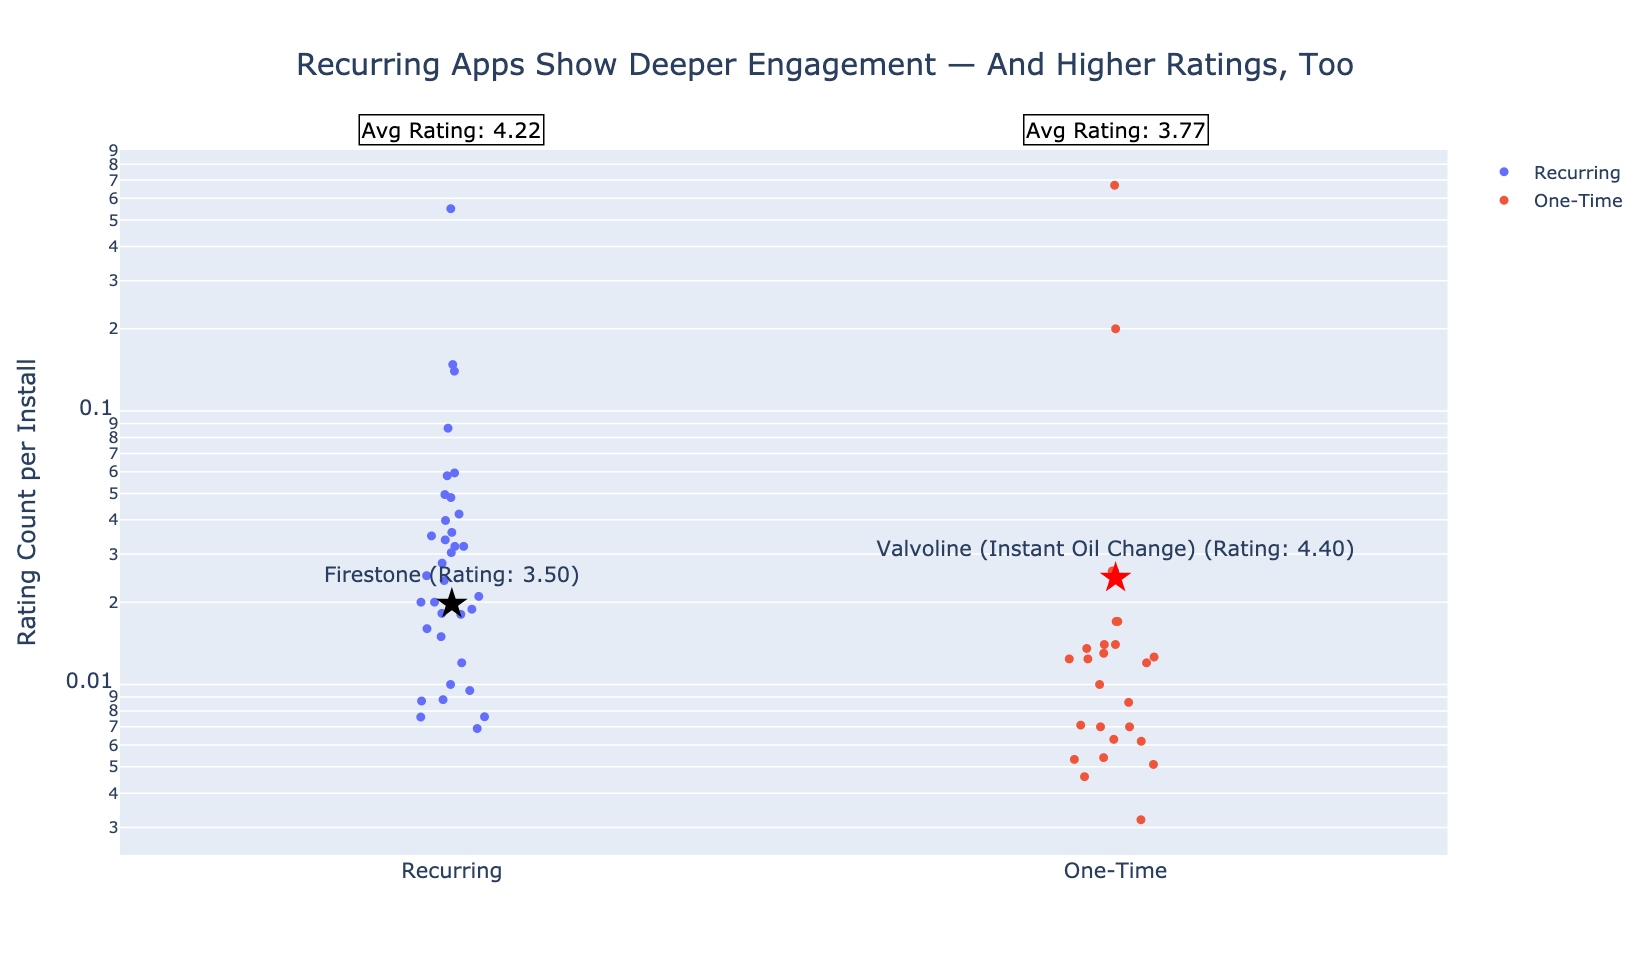

In [ ]:
fig3d = px.strip(tagged, x="Utility_Type", y="engagement_ratio", color="Utility_Type",
                  hover_name="App Name",
                  hover_data={"Rating Count": True, "Minimum Installs": ":,", "Utility_Type": False},
                  title="Iteration 4: Engagement Intensity, With Average Ratings Annotated",
                  labels={"engagement_ratio": "Rating Count per Install", "Utility_Type": ""})
fig3d.update_yaxes(type="log")

group_means = tagged.groupby("Utility_Type")["Rating"].mean()

for group in ["Recurring", "One-Time"]:
    fig3d.add_annotation(
        x=group, xref="x", yref="paper", y=1.05,
        text=f"Avg Rating: {group_means[group]:.2f}",
        showarrow=False, font=dict(size=12, color="black"),
        bgcolor="white", bordercolor="black", borderwidth=1
    )

overlays = [
    ("Firestone", firestone_row, "Recurring", "black"),
    ("Valvoline (Instant Oil Change)", valvoline_row, "One-Time", "red"),
]

for label, row, group, color in overlays:
    r = row.iloc[0]
    ratio = r["Rating Count"] / r["Minimum Installs"]
    fig3d.add_scatter(
        x=[group], y=[ratio], mode="markers+text",
        marker=dict(size=16, color=color, symbol="star"),
        text=[f"{label} (Rating: {r['Rating']:.2f})"], textposition="top center", showlegend=False,
        textfont=dict(size=14)
    )

fig3d.update_layout(
    title="Recurring Apps Show Deeper Engagement — And Higher Ratings, Too",
    title_x=0.5, title_font_size=20,
    xaxis=dict(title_font_size=16, tickfont_size=14),
    yaxis=dict(title_font_size=16, tickfont_size=14),
)
fig3d.update_annotations(font_size=14)
fig3d.write_html("/content/sample_data/chart3_iter4_annotated.html")
fig3d.show()

**Supporting chart (presentation slide 9): star ratings.** Recurring apps average 4.22★ vs 3.77★ for one-time apps, which spread much wider. Valvoline already rates 4.40★.

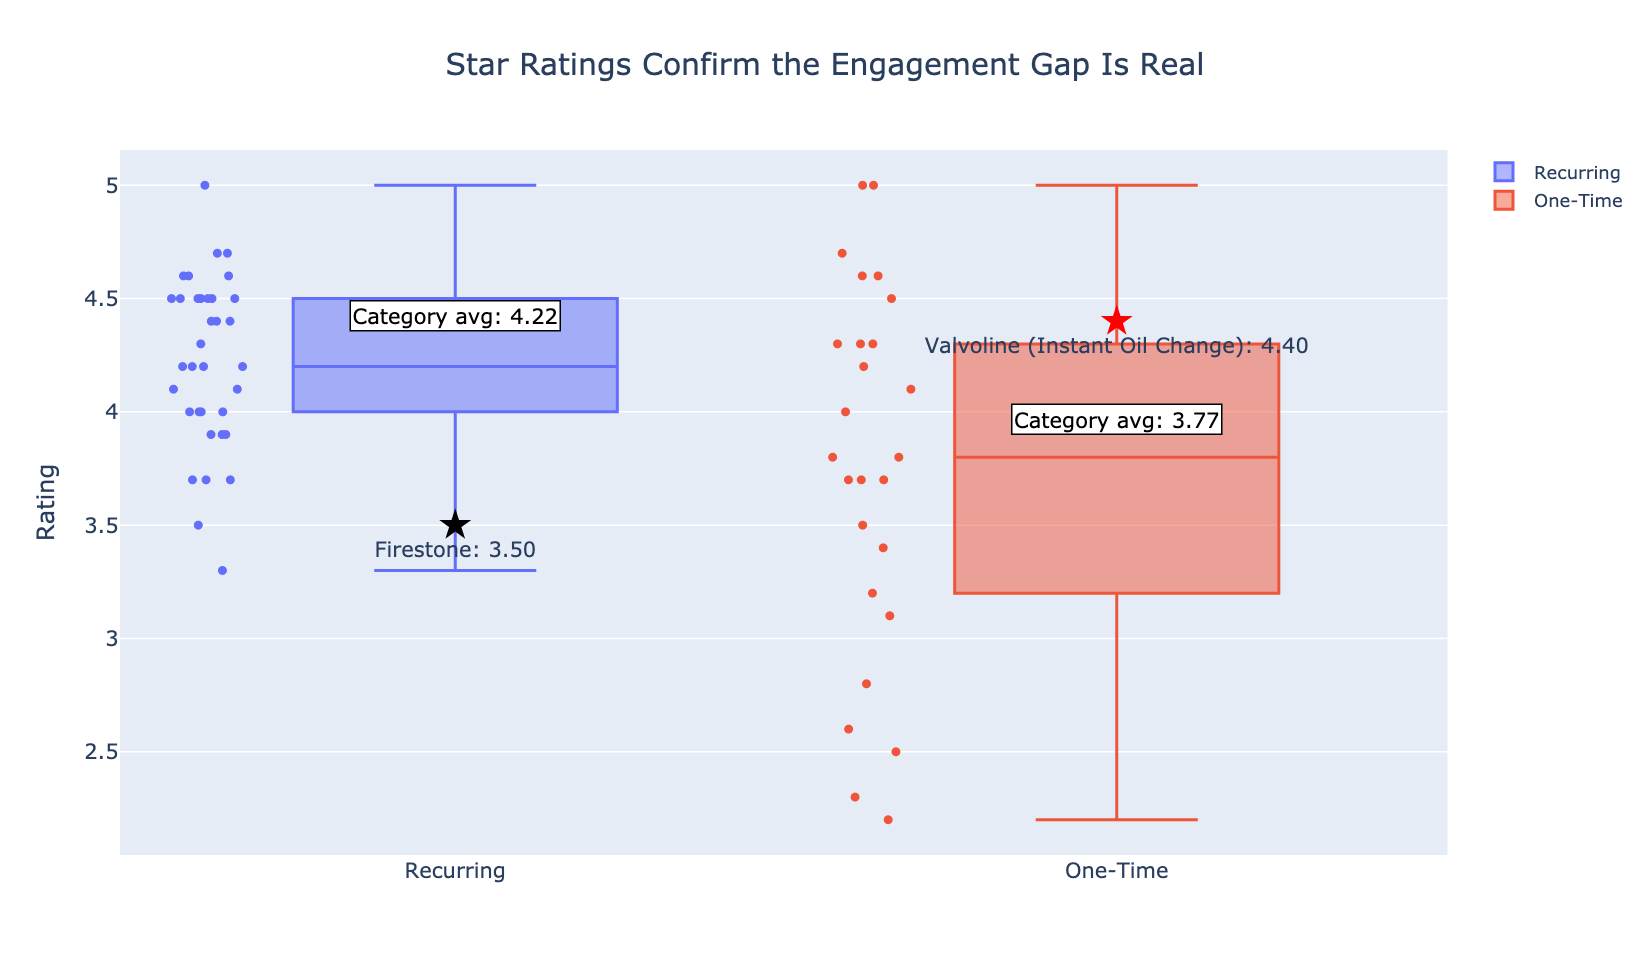

In [ ]:
fig_rating2 = px.box(tagged, x="Utility_Type", y="Rating", color="Utility_Type",
                      points="all", hover_name="App Name",
                      title="Iteration 4: Star Rating by Utility Type — Category Averages and Named Competitors",
                      labels={"Utility_Type": ""})

group_means = tagged.groupby("Utility_Type")["Rating"].mean()

for group in ["Recurring", "One-Time"]:
    fig_rating2.add_annotation(
        x=group, y=group_means[group] + 0.2,
        text=f"Category avg: {group_means[group]:.2f}",
        showarrow=False, font=dict(size=12, color="black"),
        bgcolor="white", bordercolor="black", borderwidth=1
    )

overlays = [
    ("Firestone", firestone_row, "Recurring", "black"),
    ("Valvoline (Instant Oil Change)", valvoline_row, "One-Time", "red"),
]

for label, row, group, color in overlays:
    r = row.iloc[0]
    fig_rating2.add_scatter(
        x=[group], y=[r["Rating"]], mode="markers+text",
        marker=dict(size=16, color=color, symbol="star"),
        text=[f"{label}: {r['Rating']:.2f}"], textposition="bottom center", showlegend=False,
        textfont=dict(size=14)
    )

fig_rating2.update_layout(
    title="Star Ratings Confirm the Engagement Gap Is Real",
    title_x=0.5, title_font_size=20,
    xaxis=dict(title_font_size=16, tickfont_size=14),
    yaxis=dict(title_font_size=16, tickfont_size=14),
)
fig_rating2.update_annotations(font_size=14)
fig_rating2.write_html("/content/sample_data/chart3_iter4_ratings_annotated.html")
fig_rating2.show()

## 5. Q3: What predicts installs, and do permissions matter?
**Modeling helpers**
- **Target:** `log_installs`, the log of Minimum Installs (the next cells show why).
- **Features:** app attributes (rating, rating count, size, free/ads/in-app purchases, Editors' Choice), permission features, and optionally one-hot category columns.
- **Model:** a Random Forest regressor (100 trees, max depth 10) trained on up to 400,000 sampled rows by default, scored on a held-out 20% test split. Tree models need no feature scaling.
- **Feature importance** ranks *columns* by how much they help the model. It shows association, not cause.

In [ ]:
PERM_FLAGS = ['perm_Camera', 'perm_Location', 'perm_Microphone', 'perm_Contacts', 'perm_SMS',
              'perm_Phone', 'perm_Storage', 'perm_Photos', 'perm_Calendar']
PERM_FEATURES = ['permission_count', 'num_permission_types', 'Sensitive_Access'] + PERM_FLAGS


def build_XY(data, use_general=True, use_permissions=True, use_category=True):
    """Builds the predictor table X and the target y (log installs)."""
    X = pd.DataFrame(index=data.index)
    if use_general:
        X["Rating"] = data["Rating"]
        X["Rating Count"] = data["Rating Count"]
        X["Size_MB"] = data["Size_MB"].fillna(data["Size_MB"].median())
        X["Free"] = data["Free"].astype(int)
        X["Ad Supported"] = data["Ad Supported"].astype(int)
        X["In App Purchases"] = data["In App Purchases"].astype(int)
        X["Editors Choice"] = data["Editors Choice"].astype(int)
    if use_permissions:
        for c in PERM_FEATURES:
            X[c] = data[c].astype(int)
    if use_category:
        X = pd.concat([X, pd.get_dummies(data["Category"], prefix="Category").astype(int)], axis=1)
    return X.fillna(0), data["log_installs"]


def fit_rf(X, y, sample_n=400_000, exclude_index=None):
    """Fits a Random Forest on a random sample and returns (model, R2, top-20 importances)."""
    if exclude_index is not None:
        X = X.drop(index=exclude_index, errors="ignore")
        y = y.drop(index=exclude_index, errors="ignore")
    if len(X) > sample_n:
        idx = X.sample(n=sample_n, random_state=42).index   # random_state makes the sample repeatable
        X, y = X.loc[idx], y.loc[idx]
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)
    model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
    model.fit(X_tr, y_tr)
    r2 = r2_score(y_te, model.predict(X_te))
    imp = (pd.DataFrame({"feature": X.columns, "importance": model.feature_importances_})
             .sort_values("importance", ascending=False).head(20))
    print(f"Trained on {len(X_tr):,} rows | Test R2: {r2:.3f}")
    return model, r2, imp


def tier(x):
    if x > 0.05: return "High (>0.05)"
    if x > 0.01: return "Medium (0.01-0.05)"
    return "Low (<0.01)"


def plot_importance(imp, title, r2, filename):
    imp = imp.copy()
    imp["tier"] = imp["importance"].apply(tier)
    fig = px.bar(
        imp, x="feature", y="importance", color="tier", log_y=True,
        category_orders={"feature": imp["feature"].tolist()},
        title=f"{title}<br><sup>Random Forest Model (R² = {r2:.3f}) - Top 20 Features</sup>",
        labels={"importance": "Importance Score (Log Scale)", "feature": ""},
        color_discrete_map={"High (>0.05)": "#6C63FF", "Medium (0.01-0.05)": "#F5A623", "Low (<0.01)": "#D0453D"},
    )
    top = imp.iloc[0]
    # Annotations on a log axis use log10 units for y
    fig.add_annotation(x=top["feature"], y=float(np.log10(top["importance"])),
                       text=f"Top Feature: {top['feature']}<br>Importance: {top['importance']:.4f}",
                       showarrow=True, arrowhead=2, ax=60, ay=-40, font=dict(size=18))
    fig.update_layout(
        xaxis_tickangle=-45,
        title_x=0.5,
        title_font_size=22,
        xaxis=dict(title_font_size=16, tickfont_size=14),
        yaxis=dict(title_font_size=16, tickfont_size=14),
    )
    os.makedirs("/content/sample_data", exist_ok=True)
    fig.write_html(f"/content/sample_data/{filename}")
    fig.show()
    return fig

### Why model log installs instead of raw installs
Installs are extremely skewed: the median app has 10,000, the largest 10 billion, and 135 apps exceed 100 million. Trained on raw counts, the same model scores anywhere from R² 0.18 to 0.63 depending on which apps land in the test split.

In [ ]:
# 1. How many true mega-outliers are you working with?
print(df["Minimum Installs"].describe())
print((df["Minimum Installs"] > 1e8).sum(), "apps with 100M+ installs")

X1, y1 = build_XY(df)   # y1 = log installs

# 2. Is a single split just unlucky? Try several random_states on raw installs.
for rs in [0, 1, 2, 42, 99]:
    X_tr, X_te, y_tr, y_te = train_test_split(X1, df.loc[X1.index, "Minimum Installs"],
                                               test_size=0.2, random_state=rs)
    m = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1).fit(X_tr, y_tr)
    print(rs, r2_score(y_te, m.predict(X_te)))

count    9.883100e+05
mean     4.278353e+05
std      2.314507e+07
min      0.000000e+00
25%      1.000000e+03
50%      1.000000e+04
75%      5.000000e+04
max      1.000000e+10
Name: Minimum Installs, dtype: float64
135 apps with 100M+ installs
0 0.4809171308935509
1 0.6107814491668372
2 0.3912156362116185
42 0.6284341981697326
99 0.18422811191277022


On the same 400,000-app sample, log installs score R² 0.809 while raw installs score −0.262 (worse than predicting the average).

In [ ]:
N = 400_000
Xs = X1.sample(n=N, random_state=42)

for name, target in [("log_installs", df.loc[Xs.index, "log_installs"]),
                     ("raw Minimum Installs", df.loc[Xs.index, "Minimum Installs"])]:
    X_tr, X_te, y_tr, y_te = train_test_split(Xs, target, test_size=0.2, random_state=42)
    m = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1).fit(X_tr, y_tr)
    print(name, "R2:", round(r2_score(y_te, m.predict(X_te)), 3))

log_installs R2: 0.809
raw Minimum Installs R2: -0.262


**Chart 1a and 1b (presentation slide 10): raw vs log installs, full dataset.** The raw model makes permission_count look important (0.13), which is noise from the outliers. With log installs the model is stable (R² 0.809), and Rating Count dominates.

Trained on 790,648 rows | Test R2: 0.628
                             feature  importance
1                       Rating Count    0.511583
7                   permission_count    0.127600
0                             Rating    0.055832
8               num_permission_types    0.041879
2                            Size_MB    0.035417
11                     perm_Location    0.028997
5                   In App Purchases    0.026767
61                    Category_Tools    0.021516
62           Category_Travel & Local    0.019597
32            Category_Communication    0.018077
4                       Ad Supported    0.016620
13                     perm_Contacts    0.014777
64  Category_Video Players & Editors    0.014188
52             Category_Productivity    0.011146
14                          perm_SMS    0.008948
18                     perm_Calendar    0.007826
10                       perm_Camera    0.006246
12                   perm_Microphone    0.005274
15                        pe

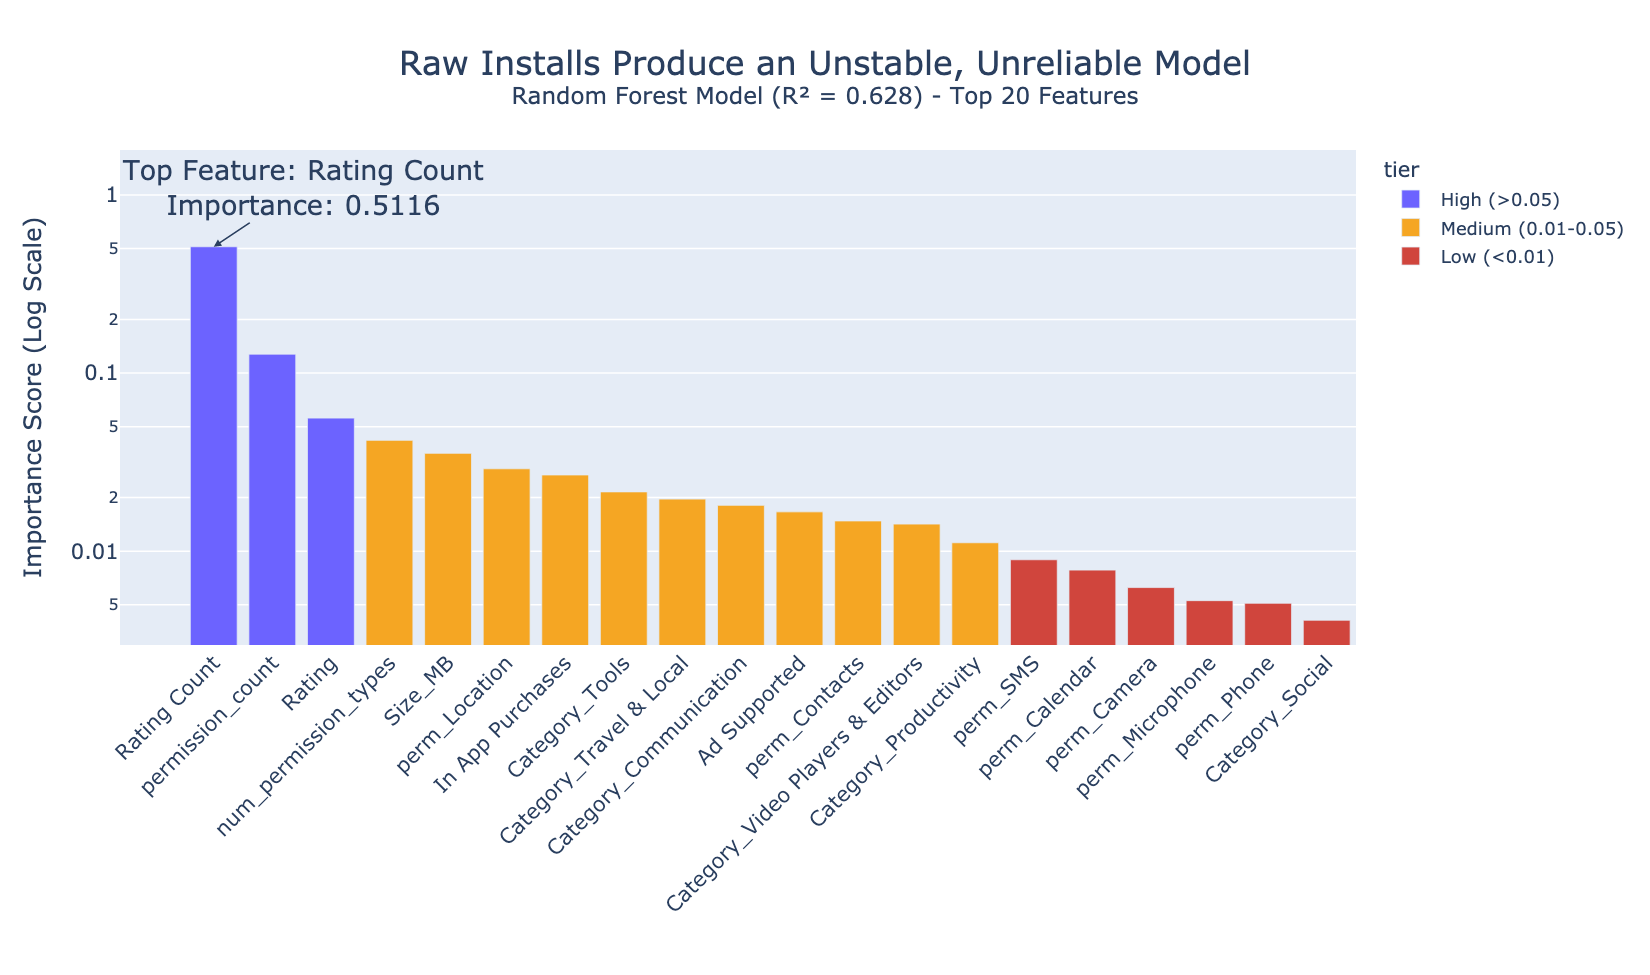

In [ ]:
X_raw = X1
y_raw = df.loc[X1.index, "Minimum Installs"]

model_rawfull, r2_rawfull, imp_rawfull = fit_rf(X_raw, y_raw, sample_n=len(X_raw))
print(imp_rawfull)

fig_rawfull = plot_importance(imp_rawfull, "Raw Installs Produce an Unstable, Unreliable Model",
                               r2_rawfull, "chart_raw_full_importance.html")

Trained on 790,648 rows | Test R2: 0.809
                       feature  importance
1                 Rating Count    0.886787
0                       Rating    0.085701
3                         Free    0.009670
4                 Ad Supported    0.008728
21             Category_Arcade    0.002130
26  Category_Books & Reference    0.001346
30             Category_Casual    0.000886
2                      Size_MB    0.000840
7             permission_count    0.000838
8         num_permission_types    0.000483
47      Category_Music & Audio    0.000302
34          Category_Education    0.000279
50    Category_Personalization    0.000220
51        Category_Photography    0.000154
20          Category_Adventure    0.000142
35        Category_Educational    0.000134
5             In App Purchases    0.000126
55       Category_Role Playing    0.000120
9             Sensitive_Access    0.000116
10                 perm_Camera    0.000086


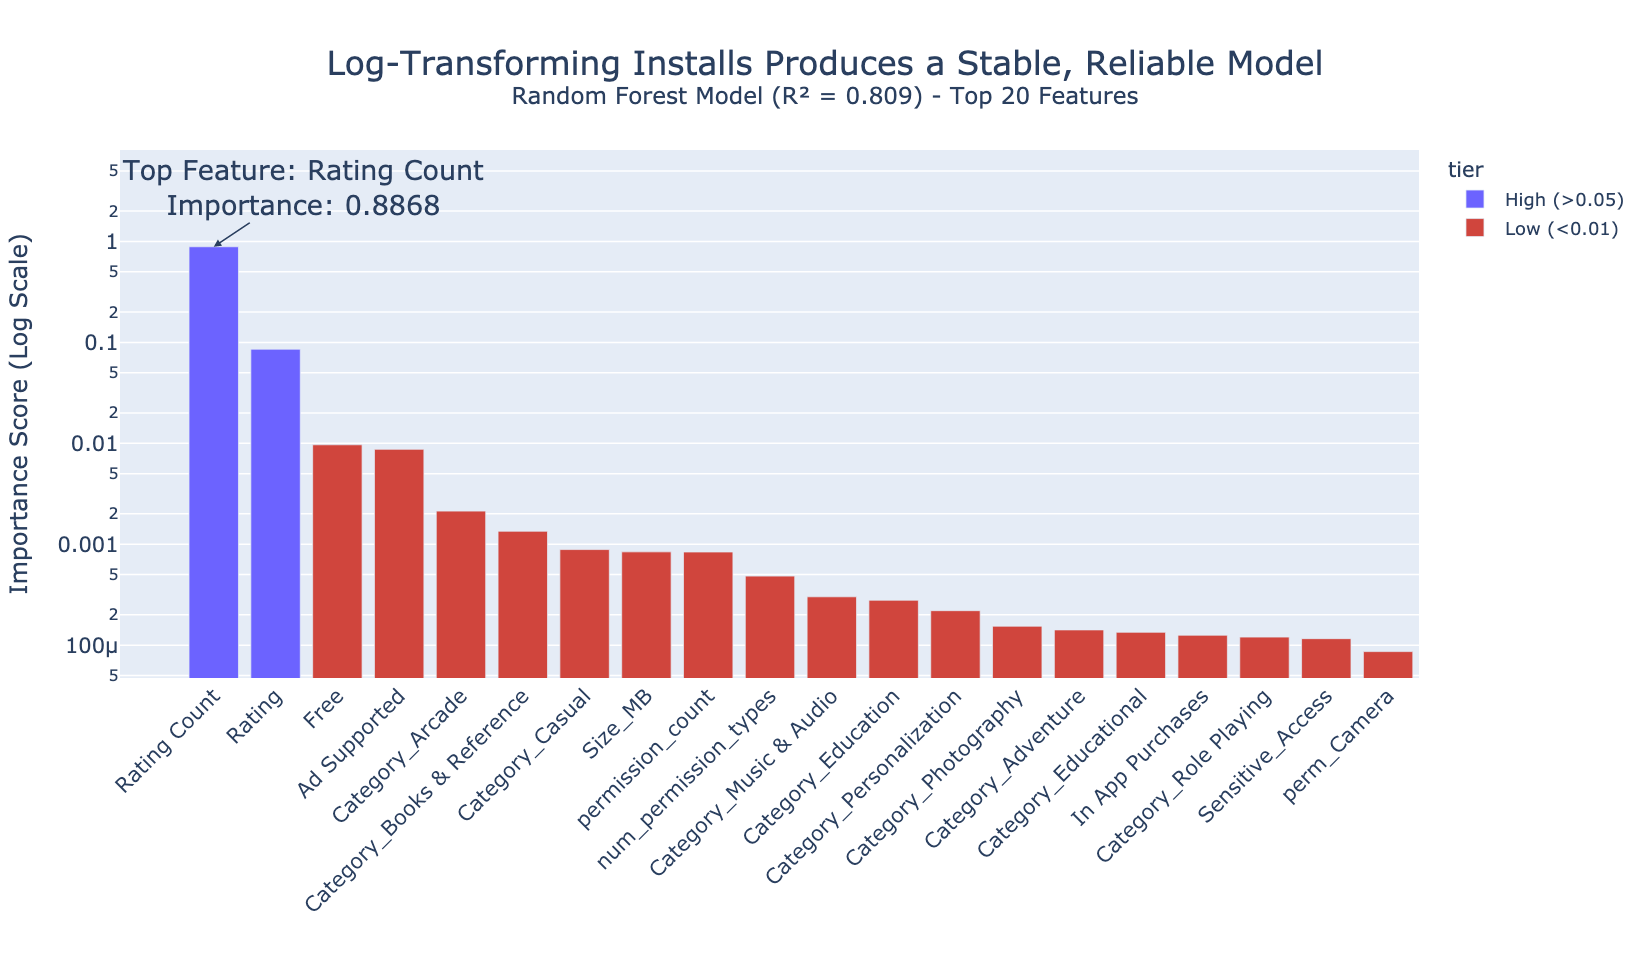

In [ ]:
model_logfull, r2_logfull, imp_logfull = fit_rf(X1, y1, sample_n=len(X1))
print(imp_logfull)

fig_logfull = plot_importance(imp_logfull, "Log-Transforming Installs Produces a Stable, Reliable Model",
                               r2_logfull, "chart_log_full_importance.html")

### Chart 2 (presentation slide 11): Auto & Vehicles only
Same features, Auto & Vehicles apps only. Category columns are dropped because a single category adds no information. Rating Count (0.779) and Rating (0.098) carry about 88% of the importance; all 12 permission features together carry about 4%.

Trained on 5,922 rows | Test R2: 0.764
                 feature  importance
1           Rating Count    0.779415
0                 Rating    0.097769
2                Size_MB    0.033455
4           Ad Supported    0.031217
7       permission_count    0.017229
3                   Free    0.013678
8   num_permission_types    0.008391
11         perm_Location    0.004522
9       Sensitive_Access    0.002282
10           perm_Camera    0.002214
5       In App Purchases    0.001967
13         perm_Contacts    0.001942
15            perm_Phone    0.001753
12       perm_Microphone    0.001391
17           perm_Photos    0.000871
18         perm_Calendar    0.000847
16          perm_Storage    0.000812
14              perm_SMS    0.000245
6         Editors Choice    0.000000


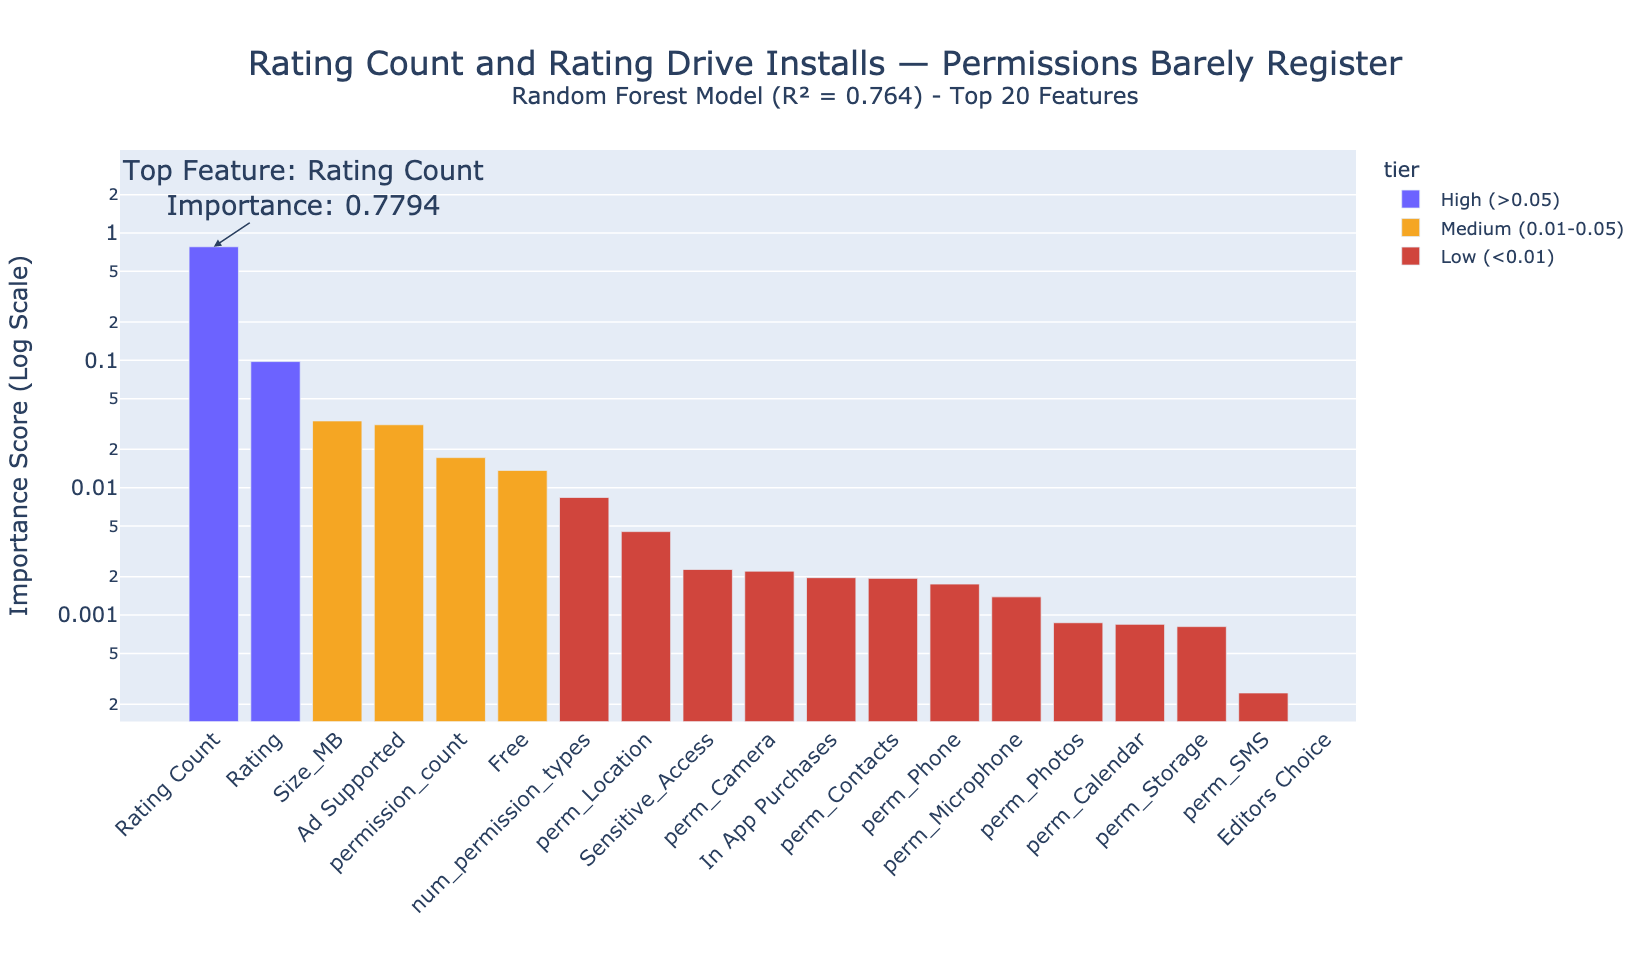

In [ ]:
multi_category = len(SCOPE_CATEGORIES) > 1      # category dummies are only useful with 2+ categories
X2, y2 = build_XY(scope, use_category=multi_category)
model2, r2_2, imp2 = fit_rf(X2, y2, exclude_index=valvoline.index)
print(imp2)
fig2 = plot_importance(imp2, "Rating Count and Rating Drive Installs — Permissions Barely Register",
                       r2_2, "chart2_category_importance.html")

### Chart 3: permissions only
Rating Count can drown out every other signal, so this model uses only the permission columns. Its low R² (0.040) is the finding: what an app asks permission for says little about its installs.

Trained on 5,922 rows | Test R2: 0.040
                 feature  importance
0       permission_count    0.406771
1   num_permission_types    0.208819
4          perm_Location    0.071033
8             perm_Phone    0.063046
3            perm_Camera    0.050371
5        perm_Microphone    0.047928
6          perm_Contacts    0.037750
11         perm_Calendar    0.037620
2       Sensitive_Access    0.021968
7               perm_SMS    0.019598
9           perm_Storage    0.018622
10           perm_Photos    0.016475


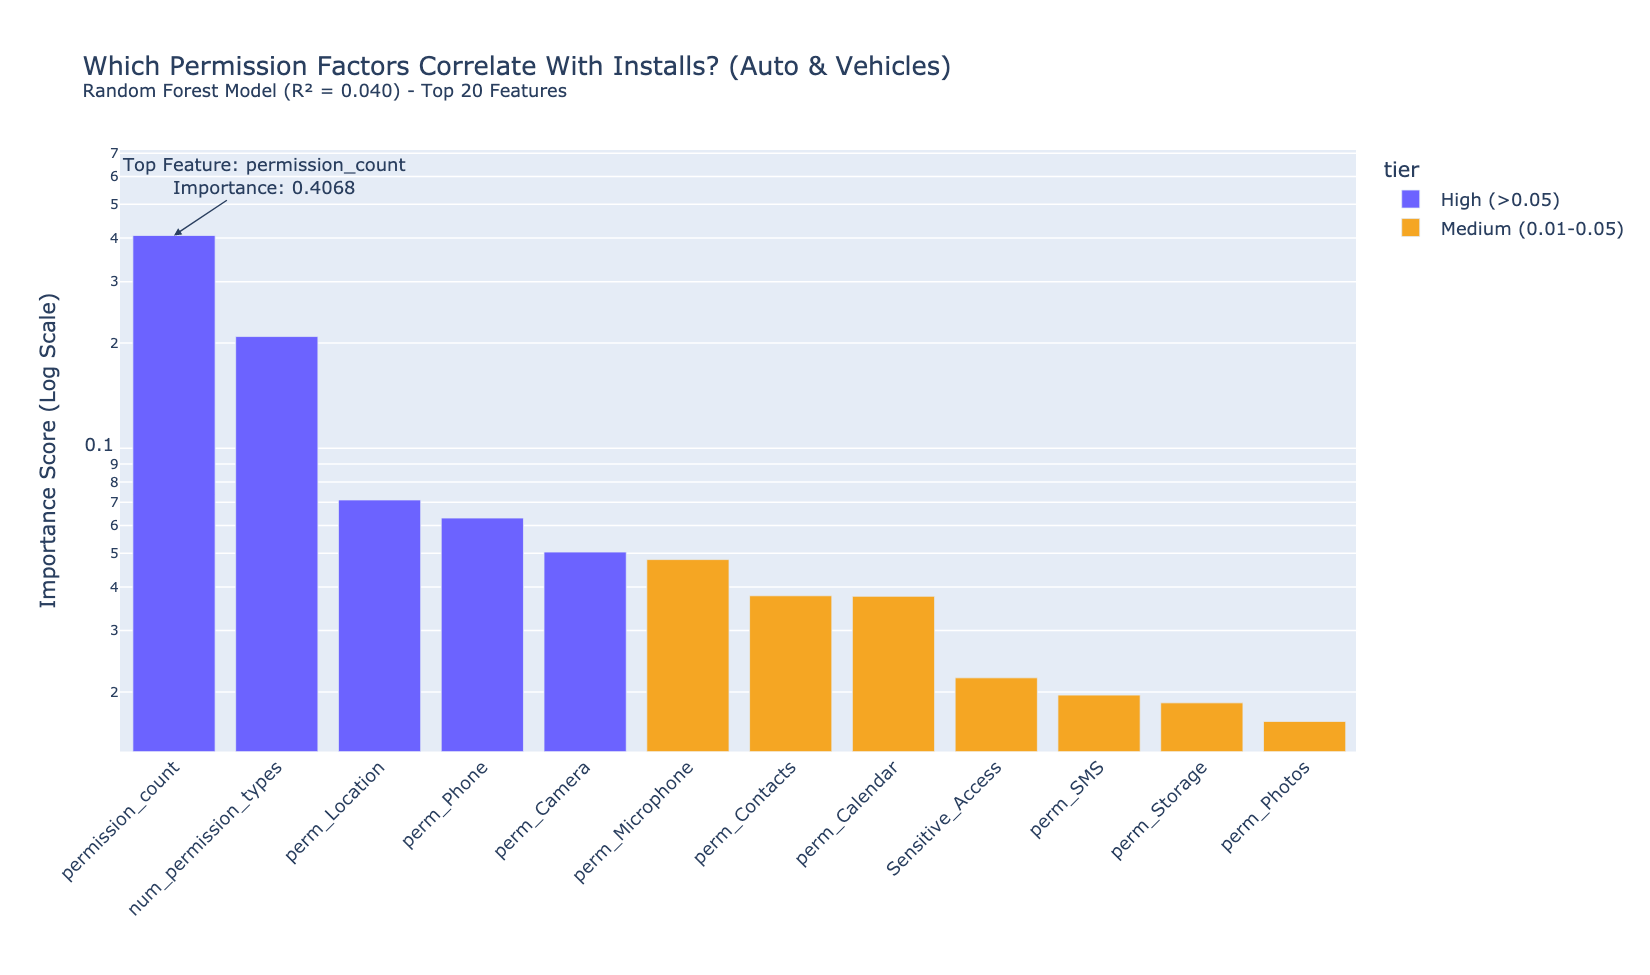

In [ ]:
X3, y3 = build_XY(scope, use_general=False, use_permissions=True, use_category=False)
model3, r2_3, imp3 = fit_rf(X3, y3, exclude_index=valvoline.index)
print(imp3)
fig3 = plot_importance(imp3, "Which Permission Factors Correlate With Installs? (Auto & Vehicles)",
                       r2_3, "chart3_permissions_importance.html")

### Predicting installs for the named apps
The Chart 2 model predicts an app's installs from its features, with that app held out of training. A ratio near 1.0 means the app performs about as its ratings and features suggest. Actual installs are Google's bucket floor (100,000 means somewhere from 100,000 to 500,000). Valvoline's app is listed under Shopping, so its prediction is a rough cross-check only.

In [ ]:
valvoline_X, _ = build_XY(valvoline, use_category=multi_category)
valvoline_X = valvoline_X.reindex(columns=X2.columns, fill_value=0)

pred = float(np.expm1(model2.predict(valvoline_X)[0]))
actual = float(valvoline["Minimum Installs"].iloc[0])
print(f"Predicted installs: {pred:,.0f}")
print(f"Actual installs:    {actual:,.0f}")
print(f"Predicted / actual: {pred / actual:.2f}")

Predicted installs: 81,014
Actual installs:    100,000
Predicted / actual: 0.81


My Firestone was predicted the same way, held out in place of Valvoline: **96,323 predicted vs 100,000 actual (0.96)**, so it performs about as expected for its ratings.

## 6. Q4: Which revenue model should the app use?
Share of Auto & Vehicles apps rated 4.0★ or higher by monetization type. 97.7% are free to download; the final styled version is made in section 7.

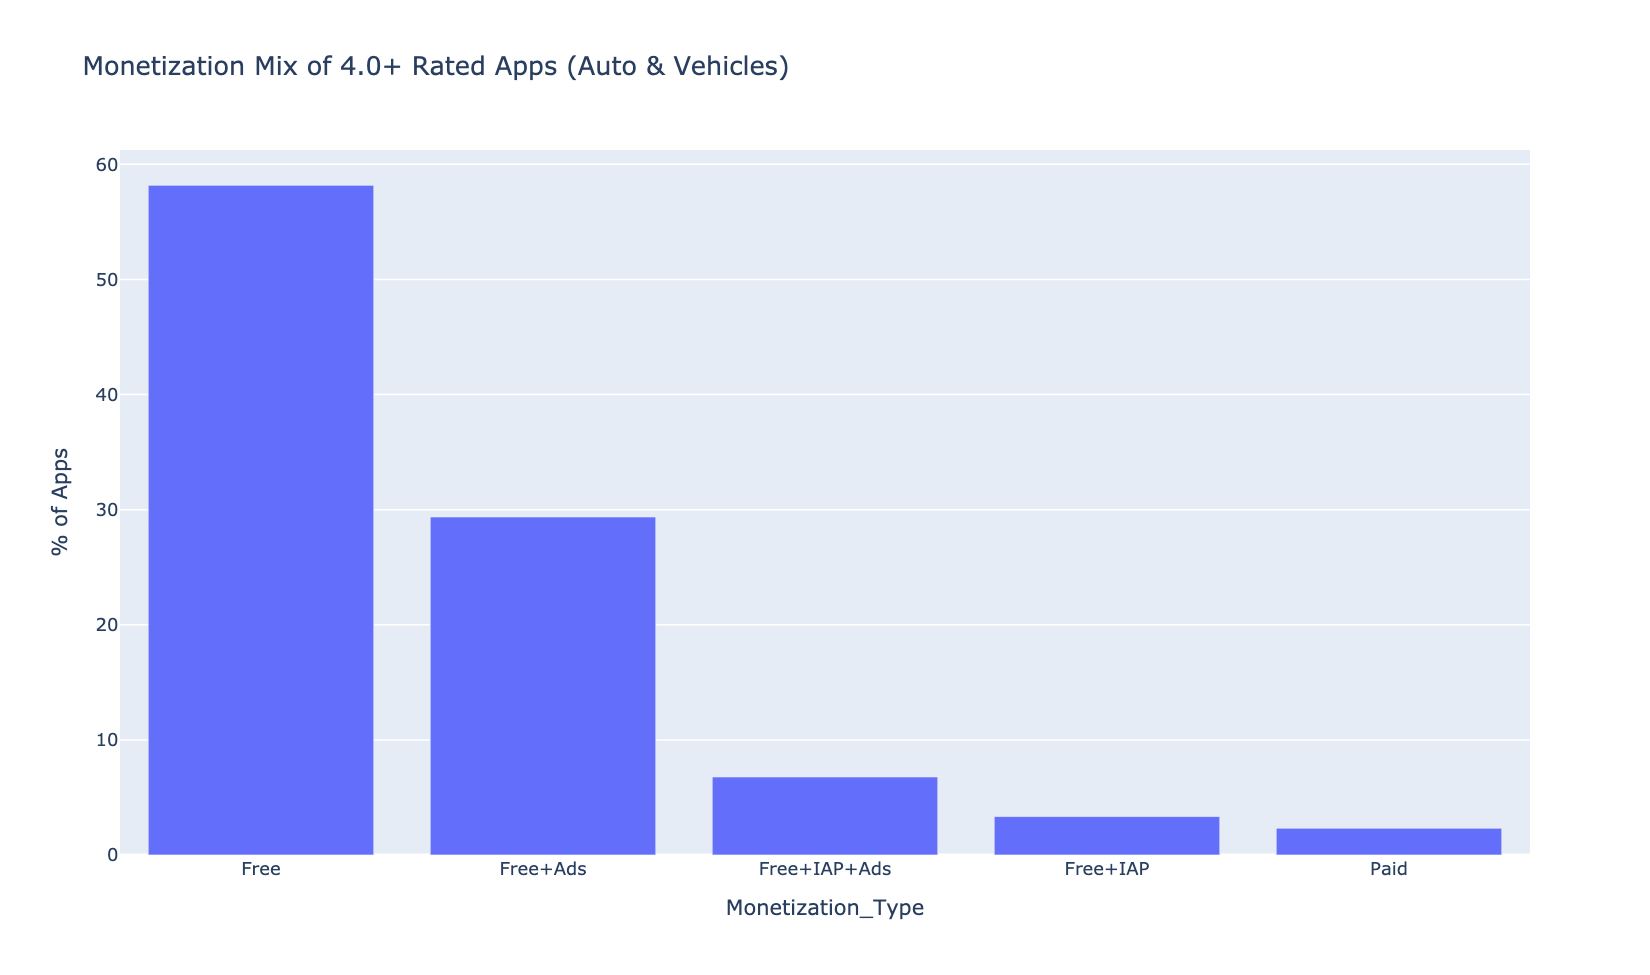

In [ ]:
top_rated = scope[scope["Rating"] >= 4.0]
mix = (top_rated["Monetization_Type"].value_counts(normalize=True).mul(100).reset_index())
mix.columns = ["Monetization_Type", "Percent"]
fig6 = px.bar(mix, x="Monetization_Type", y="Percent",
              title="Monetization Mix of 4.0+ Rated Apps (Auto & Vehicles)",
              labels={"Percent": "% of Apps"})
fig6.write_html("/content/sample_data/chart6_monetization_mix.html")
fig6.show()

## 7. Export charts for the presentation
Full-page, responsive HTML versions of the slide 9 and slide 10 charts (published with GitHub Pages and linked from the slides), and the styled monetization chart as a PNG.

In [ ]:
out = "/content/drive/MyDrive/Colab Notebooks/"

# Interactive HTML for slides 9 and 10
for fig, name in [(fig_rating2, "slide9_star_ratings.html"),
                  (fig3d,       "slide10_engagement_and_ratings.html")]:
    fig.write_html(out + name,
                   include_plotlyjs=True,
                   full_html=True,
                   default_width="100%",
                   default_height="100vh",
                   config={"responsive": True, "displaylogo": False})
    files.download(out + name)

# Monetization chart as PNG, styled to match the other charts
fig6.update_traces(texttemplate="%{y:.1f}%", textposition="outside")
fig6.update_layout(
    title="Monetization Mix of 4.0★+ Auto & Vehicles Apps",
    title_x=0.5, title_font_size=20,
    xaxis=dict(title="", title_font_size=16, tickfont_size=14,
               categoryorder="total descending"),
    yaxis=dict(title="% of 4.0★+ Rated Apps", title_font_size=16, tickfont_size=14),
)
fig6.write_image(out + "fig6_monetization_mix.png", width=1400, height=900, scale=2)
files.download(out + "fig6_monetization_mix.png")
print("Done: 2 HTML files + 1 PNG saved to Drive and downloaded")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Done: 2 HTML files + 1 PNG saved to Drive and downloaded
